In [ ]:
import tensorflow as tf
import numpy as np

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize the images to be between -1 and 1
train_images = (train_images.astype('float32') - 127.5) / 127.5
test_images = (test_images.astype('float32') - 127.5) / 127.5

# Add a channel dimension if not present
if train_images.shape[-1] != 3:
    train_images = np.expand_dims(train_images, axis=-1)
    test_images = np.expand_dims(test_images, axis=-1)

# Print the shapes of the training and testing image data
print(f"Training images shape: {train_images.shape}")
print(f"Testing images shape: {test_images.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)


In [ ]:
from tensorflow.keras.layers import Dense, Reshape, Conv2DTranspose, BatchNormalization, LeakyReLU
from tensorflow.keras import Sequential

def make_generator_model(latent_dim):
    model = Sequential()

    # Step 4: Start with a Dense layer and reshape
    model.add(Dense(4*4*256, use_bias=False, input_shape=(latent_dim,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Reshape((4, 4, 256)))
    assert model.output_shape == (None, 4, 4, 256) # Optional: check the shape

    # Step 5 & 6: Add Conv2DTranspose, BatchNormalization, and LeakyReLU layers
    model.add(Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 4, 4, 128)
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 8, 8, 64)
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 32)
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    # Step 7: Final layer
    model.add(Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 32, 32, 3)

    return model

# Example usage (optional, for testing):
# latent_dim_size = 100
# generator = make_generator_model(latent_dim_size)
# generator.summary()

In [ ]:
from tensorflow.keras.layers import Conv2D, Dropout

def make_discriminator_model():
    model = Sequential()

    # Step 1: Add Conv2D, LeakyReLU, and Dropout layers
    model.add(Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[32, 32, 3]))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # Step 2: Add another set of Conv2D, LeakyReLU, and Dropout layers
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # Step 3: Add the final Dense layer for classification
    model.add(tf.keras.layers.Flatten())
    model.add(Dense(1))

    return model

# Example usage (optional, for testing):
# discriminator = make_discriminator_model()
# discriminator.summary()

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [ ]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# Task
Implement a GAN training loop including a training step function, checkpoint setup, and image generation/saving within the loop.

## Define the training step

### Subtask:
Create a function that performs one training step for both the generator and discriminator.


**Reasoning**:
The subtask requires defining a training step function for the GAN. This involves using `tf.GradientTape` to compute gradients and applying them using the defined optimizers. I will group steps 1 through 10 of the instructions into a single code block to define the `train_step` function.



In [ ]:
import tensorflow as tf

# Define BATCH_SIZE and latent_dim (assuming these are not defined globally yet)
# You might want to adjust these based on your needs and available memory
BATCH_SIZE = 256
latent_dim = 100

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

## Set up checkpoints

### Subtask:
Configure checkpoints to save the model's progress during training.


**Reasoning**:
Configure checkpoints by creating a Checkpoint object, defining a checkpoint directory, and setting up a CheckpointManager.



In [ ]:
import os

# Instantiate the generator and discriminator models
generator = make_generator_model(latent_dim)
discriminator = make_discriminator_model()

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)
manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=5)

# Restore the latest checkpoint if it exists
if manager.latest_checkpoint:
    checkpoint.restore(manager.latest_checkpoint)
    print ('Latest checkpoint restored!!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Implement the training loop

### Subtask:
Write the main training loop that iterates over epochs and batches, calling the training step function.


**Reasoning**:
Write the main training loop as requested, which iterates over epochs and batches, calls the training step, saves checkpoints, and prints epoch times.



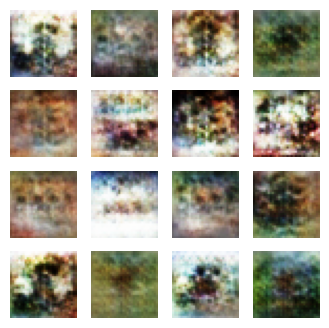

Time for epoch 50 is 9.617112159729004 sec


'./training_checkpoints/ckpt-10'

In [ ]:
import time
from IPython import display

EPOCHS = 50

# Prepare the training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(100000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Training loop
for epoch in range(EPOCHS):
    start = time.time()

    for image_batch in train_dataset:
        train_step(image_batch)

    # Produce images for the GIF as we go
    display.clear_output(wait=True)
    generate_and_save_images(generator, epoch + 1, seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
        manager.save()

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

# Save the final checkpoint
manager.save()

Found 50 generated images.
Displaying 5 generated images:


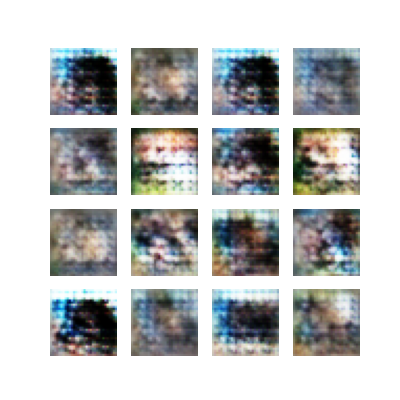

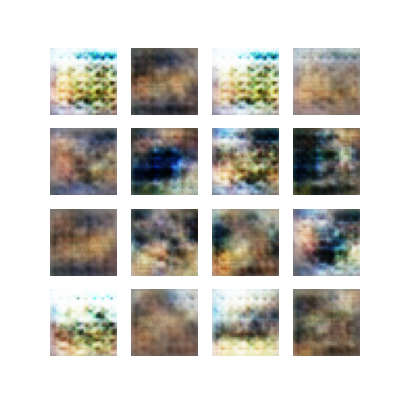

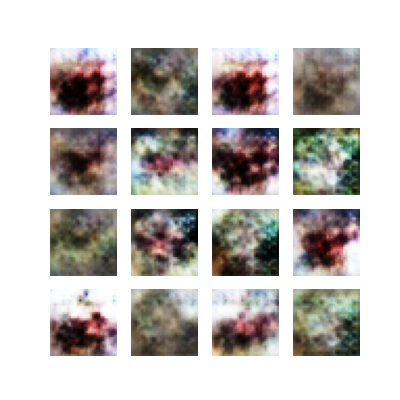

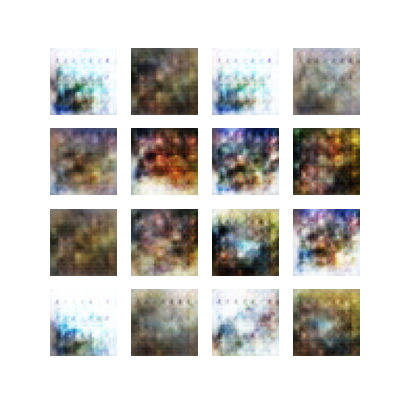

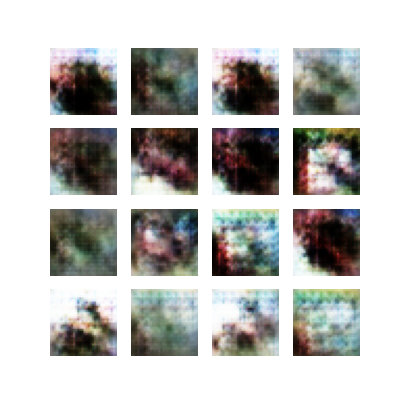

In [ ]:
import matplotlib.pyplot as plt
import os
from IPython.display import Image, display

generated_image_files = [f for f in os.listdir('generated_images') if f.endswith('.png')]
generated_image_files.sort()

print(f"Found {len(generated_image_files)} generated images.")

# Display a few of the generated images
num_images_to_display = min(5, len(generated_image_files)) # Display at most 5 images

if num_images_to_display > 0:
    print(f"Displaying {num_images_to_display} generated images:")
    for i in range(num_images_to_display):
        display(Image(filename=os.path.join('generated_images', generated_image_files[i])))
else:
    print("No generated images found to display.")

In [ ]:
import matplotlib.pyplot as plt
import os

# Create a directory to save generated images
if not os.path.exists('generated_images'):
    os.makedirs('generated_images')

def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False.
    # This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        # Denormalize the image
        img = (predictions[i, :, :, :] * 127.5 + 127.5).numpy().astype('uint8')
        plt.imshow(img)
        plt.axis('off')

    plt.savefig('generated_images/image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

# Define a fixed noise vector for visualization
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, latent_dim])

# Modify the training loop to include image generation and saving
# Re-run the training loop cell after this cell is executed

# Training loop (add the image generation and saving part)
# for epoch in range(EPOCHS):
#     start = time.time()

#     for image_batch in train_dataset:
#         train_step(image_batch)

#     # Produce images for the GIF as we go
#     display.clear_output(wait=True)
#     generate_and_save_images(generator, epoch + 1, seed)

#     # Save the model every 15 epochs
#     if (epoch + 1) % 15 == 0:
#         manager.save()

#     print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

# # Save the final checkpoint
# manager.save()